In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Hardcoded option table from your data
data = pd.DataFrame({
    "Strike": [
        275.00, 277.50, 280.00, 282.50, 285.00,
        287.50, 290.00, 292.50, 295.00, 297.50,
        300.00, 302.50, 305.00, 307.50, 310.00,
        312.50, 315.00, 317.50, 320.00, 325.00
    ],
    "Moneyness_pct": [
        7.99, 7.15, 6.31, 5.48, 4.64,
        3.80, 2.97, 2.13, 1.29, 0.46,
        -0.38, -1.21, -2.05, -2.89, -3.72,
        -4.56, -5.40, -6.23, -7.07, -8.74
    ],
    "Bid": [
        23.85, 20.05, 18.90, 16.30, 13.95,
        11.55, 9.20, 7.00, 4.95, 3.35,
        2.09, 1.23, 0.70, 0.39, 0.22,
        0.12, 0.08, 0.03, 0.02, 0.00
    ],
    "Mid": [
        24.18, 21.48, 19.20, 16.68, 14.25,
        11.83, 9.45, 7.23, 5.15, 3.50,
        2.19, 1.29, 0.75, 0.43, 0.25,
        0.14, 0.08, 0.04, 0.03, 0.03
    ],
    "Ask": [
        24.50, 22.90, 19.50, 17.05, 14.55,
        12.10, 9.70, 7.45, 5.35, 3.65,
        2.29, 1.35, 0.79, 0.46, 0.27,
        0.16, 0.09, 0.05, 0.04, 0.06
    ],
    "Volume": [
        510, 73, 2427, 145, 2872,
        2549, 8419, 6938, 27813, 36306,
        136036, 27274, 34806, 6986, 23935,
        3450, 4437, 654, 2643, 804
    ],
    "OpenInterest": [
        17572, 2586, 33497, 4639, 29960,
        6007, 30119, 11247, 32703, 11300,
        81123, 12800, 23403, 3941, 20208,
        1191, 11122, 88, 14373, 3200
    ],
    "IV_pct": [
        67.44, 66.68, 63.24, 49.73, 45.53,
        42.76, 39.68, 34.47, 32.76, 31.00,
        30.35, 30.28, 31.56, 32.28, 33.23,
        35.93, 37.00, 36.86, 40.94, 44.96
    ],
    "Delta": [
        0.9550, 0.9371, 0.9223, 0.9398, 0.9239,
        0.8938, 0.8523, 0.8063, 0.7113, 0.5869,
        0.4409, 0.3017, 0.1977, 0.1206, 0.0712,
        0.0488, 0.0288, 0.0140, 0.0128, 0.0063
    ]
})

# Convert percentages to decimals
data["Moneyness"] = data["Moneyness_pct"] / 100
data["IV"] = data["IV_pct"] / 100

# Estimate S_t from the table's moneyness definition:
# Moneyness = (S_t - K) / S_t
# Therefore: S_t = K / (1 - Moneyness)
data["S_t_implied"] = data["Strike"] / (1 - data["Moneyness"])

# Use the median implied S_t as the underlying spot
S_t = data["S_t_implied"].median()

# Normalized strike
data["K_over_S"] = data["Strike"] / S_t

print(f"Estimated S_t = {S_t:.2f}")
print(data[["Strike", "K_over_S", "Moneyness_pct", "IV_pct"]])

Estimated S_t = 298.87
    Strike  K_over_S  Moneyness_pct  IV_pct
0    275.0  0.920130           7.99   67.44
1    277.5  0.928495           7.15   66.68
2    280.0  0.936860           6.31   63.24
3    282.5  0.945225           5.48   49.73
4    285.0  0.953590           4.64   45.53
5    287.5  0.961955           3.80   42.76
6    290.0  0.970319           2.97   39.68
7    292.5  0.978684           2.13   34.47
8    295.0  0.987049           1.29   32.76
9    297.5  0.995414           0.46   31.00
10   300.0  1.003779          -0.38   30.35
11   302.5  1.012143          -1.21   30.28
12   305.0  1.020508          -2.05   31.56
13   307.5  1.028873          -2.89   32.28
14   310.0  1.037238          -3.72   33.23
15   312.5  1.045603          -4.56   35.93
16   315.0  1.053968          -5.40   37.00
17   317.5  1.062332          -6.23   36.86
18   320.0  1.070697          -7.07   40.94
19   325.0  1.087427          -8.74   44.96


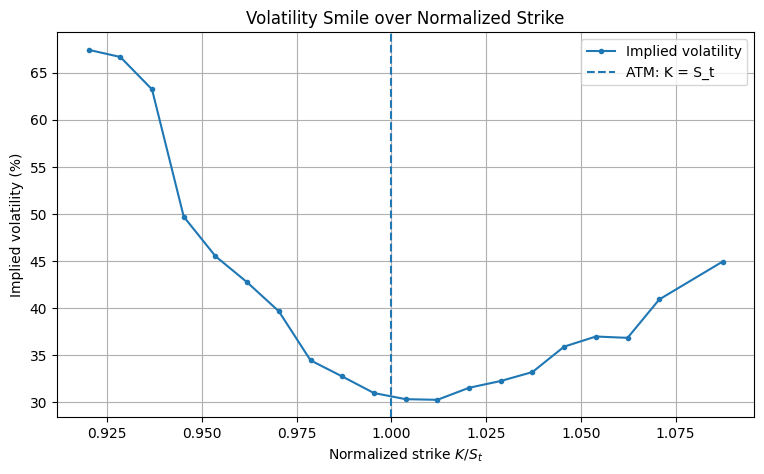

In [2]:
plt.figure(figsize=(9, 5))

plt.plot(data["K_over_S"], data["IV_pct"], ".-", label="Implied volatility")

plt.axvline(1.0, linestyle="--", label="ATM: K = S_t")

plt.xlabel(r"Normalized strike $K/S_t$")
plt.ylabel("Implied volatility (%)")
plt.title("Volatility Smile over Normalized Strike")
plt.legend()
plt.grid(True)
plt.show()